In [1]:
# ==============================
# BFS & DFS on Tree and Graph
# ==============================

from collections import deque

# ------------------------------
# TREE EXAMPLE
# ------------------------------

print("===== TREE TRAVERSAL =====")

tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [],
    'E': [],
    'F': [],
    'G': []
}

# BFS for Tree
def bfs_tree(tree, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(tree[node])

    return visited

# DFS for Tree
def dfs_tree(tree, node, visited=None):
    if visited is None:
        visited = []

    visited.append(node)

    for neighbor in tree[node]:
        if neighbor not in visited:
            dfs_tree(tree, neighbor, visited)

    return visited

print("BFS (Tree):", bfs_tree(tree, 'A'))
print("DFS (Tree):", dfs_tree(tree, 'A'))


# ------------------------------
# GRAPH EXAMPLE
# ------------------------------

print("\n===== GRAPH TRAVERSAL =====")

graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'E'],
    'D': ['B'],
    'E': ['B', 'C']
}

# BFS for Graph
def bfs_graph(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])

    return visited

# DFS for Graph
def dfs_graph(graph, node, visited=None):
    if visited is None:
        visited = []

    visited.append(node)

    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs_graph(graph, neighbor, visited)

    return visited

print("BFS (Graph):", bfs_graph(graph, 'A'))
print("DFS (Graph):", dfs_graph(graph, 'A'))


# ------------------------------
# FINAL MESSAGE
# ------------------------------
print("\nProgram executed successfully ✅")

===== TREE TRAVERSAL =====
BFS (Tree): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
DFS (Tree): ['A', 'B', 'D', 'E', 'C', 'F', 'G']

===== GRAPH TRAVERSAL =====
BFS (Graph): ['A', 'B', 'C', 'D', 'E']
DFS (Graph): ['A', 'B', 'D', 'E', 'C']

Program executed successfully ✅



Processing size: 1000

Processing size: 40000

Processing size: 80000

Processing size: 200000

Processing size: 1000000

===== RESULT TABLE =====
   Input Size  BFS Time (sec)  DFS Time (sec)
0        1000        0.000168        0.000129
1       40000        0.012321        0.008235
2       80000        0.023795        0.019763
3      200000        0.121693        0.084160
4     1000000        0.260418        0.240713


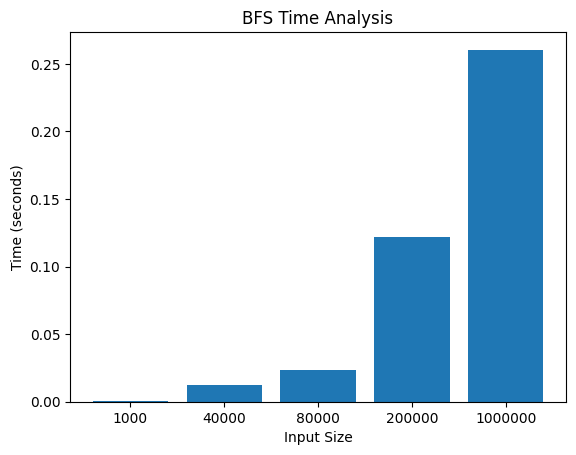

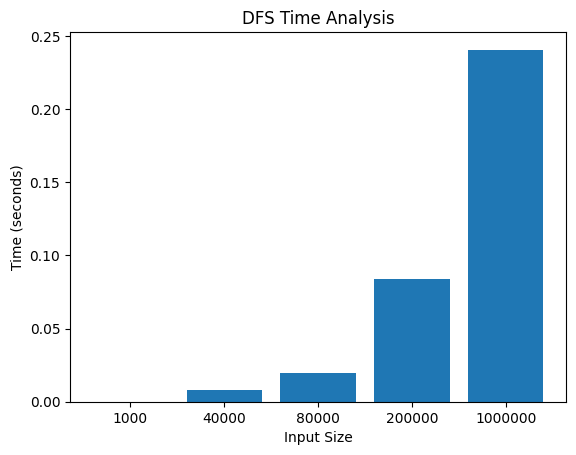


Task 2 Completed ✅


In [2]:
# ==========================================
# TASK 2: BFS vs DFS Timing Analysis
# ==========================================

import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# Input sizes
sizes = [1000, 40000, 80000, 200000, 1000000]

bfs_times = []
dfs_times = []

# Linear tree/graph generator (safe for large input)
def create_graph(n):
    graph = {}
    for i in range(n):
        if i+1 < n:
            graph[i] = [i+1]
        else:
            graph[i] = []
    return graph

# BFS with goal
def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node == goal:
            return True
        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])
    return False

# DFS (iterative to avoid recursion error)
def dfs(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()
        if node == goal:
            return True
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])
    return False


# MAIN LOOP
for size in sizes:
    print(f"\nProcessing size: {size}")

    # Generate unique random list
    data = random.sample(range(size * 10), size)

    graph = create_graph(size)

    goal_index = size - 220   # given condition
    goal = goal_index

    # BFS Timing
    start_time = time.time()
    bfs(graph, 0, goal)
    bfs_time = time.time() - start_time
    bfs_times.append(bfs_time)

    # DFS Timing
    start_time = time.time()
    dfs(graph, 0, goal)
    dfs_time = time.time() - start_time
    dfs_times.append(dfs_time)


# DataFrame
df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time (sec)": bfs_times,
    "DFS Time (sec)": dfs_times
})

print("\n===== RESULT TABLE =====")
print(df)


# BAR CHART
plt.figure()
x = range(len(sizes))

plt.bar(x, bfs_times)
plt.xticks(x, sizes)
plt.title("BFS Time Analysis")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.show()

plt.figure()
plt.bar(x, dfs_times)
plt.xticks(x, sizes)
plt.title("DFS Time Analysis")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.show()


print("\nTask 2 Completed ✅")

In [3]:
# ==========================================
# TASK 3: Shortest Path (BFS)
# Islamabad → Karachi
# ==========================================

from collections import deque

# Graph (Cities connection)
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

# BFS Shortest Path Function
def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        # Goal check
        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None


# Run
start_city = "Islamabad"
goal_city = "Karachi"

shortest_path = bfs_shortest_path(graph, start_city, goal_city)

# Output
print("===== SHORTEST PATH USING BFS =====")
print("Start:", start_city)
print("Goal:", goal_city)

if shortest_path:
    print("Shortest Path:", " → ".join(shortest_path))
    print("Number of Cities:", len(shortest_path))
else:
    print("No path found ❌")

print("\nTask 3 Completed ✅")

===== SHORTEST PATH USING BFS =====
Start: Islamabad
Goal: Karachi
Shortest Path: Islamabad → Rawalpindi → Quetta → Karachi
Number of Cities: 4

Task 3 Completed ✅
